In [1]:
# Imports necesarios
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import sys

# Agregar src al path para importar nuestras funciones
sys.path.append('../src')

# Configuración de visualizaciones
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Configuración de pandas para mostrar más columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Funciones adaptadas para los datos reales
def load_trips_adapted(input_dir: Path) -> pd.DataFrame:
    """Carga todos los CSV de viajes en un solo DataFrame con columnas adaptadas."""
    files = sorted(input_dir.glob('*.csv'))
    dfs = []
    for f in files:
        df = pd.read_csv(
            f,
            parse_dates=["fecha_origen_recorrido", "fecha_destino_recorrido"],
            dayfirst=True,
        )
        dfs.append(df)
    if not dfs:
        raise FileNotFoundError("No se encontraron CSV en " + str(input_dir))
    return pd.concat(dfs, ignore_index=True)

def load_users_adapted(input_dir: Path) -> pd.DataFrame:
    """Carga todos los CSV de usuarios en un solo DataFrame."""
    files = sorted(input_dir.glob('*.csv'))
    dfs = []
    for f in files:
        df = pd.read_csv(
            f,
            parse_dates=["fecha_alta"],
            dayfirst=True,
        )
        dfs.append(df)
    if not dfs:
        raise FileNotFoundError("No se encontraron CSV en " + str(input_dir))
    return pd.concat(dfs, ignore_index=True)

def compute_counts_adapted(df: pd.DataFrame, dt_minutes: int = 30) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Devuelve dos DataFrames con conteos de partidas y arribos por estación (versión adaptada)."""
    df = df.copy()
    df["window_dispatch"] = df["fecha_origen_recorrido"].dt.floor(f"{dt_minutes}min")
    df["window_arrival"] = df["fecha_destino_recorrido"].dt.floor(f"{dt_minutes}min")

    dispatch = (
        df.groupby(["window_dispatch", "id_estacion_origen"])
        .size()
        .reset_index(name="dispatch_count")
        .rename(columns={"window_dispatch": "timestamp", "id_estacion_origen": "station_id"})
    )

    arrival = (
        df.groupby(["window_arrival", "id_estacion_destino"])
        .size()
        .reset_index(name="arrival_count")
        .rename(columns={"window_arrival": "timestamp", "id_estacion_destino": "station_id"})
    )

    return dispatch, arrival

print("✅ Librerías importadas correctamente")
print("✅ Funciones adaptadas para datos reales definidas")


✅ Librerías importadas correctamente
✅ Funciones adaptadas para datos reales definidas


In [2]:
# Carga de datos de viajes y usuarios
trips_path = Path("../data/raw/trips")
users_path = Path("../data/raw/users")

print(f"📁 Cargando datos de viajes desde: {trips_path}")
print(f"📁 Cargando datos de usuarios desde: {users_path}")

# Cargar datos de viajes usando función adaptada
print("\n🚲 Cargando datos de viajes...")
trips_df = load_trips_adapted(trips_path)

print(f"\n📊 Datos de viajes cargados:")
print(f"   • Filas: {len(trips_df):,}")
print(f"   • Columnas: {len(trips_df.columns)}")
print(f"   • Período: {trips_df['fecha_origen_recorrido'].min()} - {trips_df['fecha_origen_recorrido'].max()}")
print(f"   • Memoria: {trips_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Cargar datos de usuarios
print("\n👥 Cargando datos de usuarios...")
users_df = load_users_adapted(users_path)

print(f"\n📊 Datos de usuarios cargados:")
print(f"   • Filas: {len(users_df):,}")
print(f"   • Columnas: {len(users_df.columns)}")
print(f"   • Período registro: {users_df['fecha_alta'].min()} - {users_df['fecha_alta'].max()}")
print(f"   • Memoria: {users_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Mostrar estructura de datos
print("\n🏗️ Estructura de datos de viajes:")
print(trips_df.info())

print("\n🏗️ Estructura de datos de usuarios:")
print(users_df.info())

print("\n👀 Primeras filas de viajes:")
display(trips_df.head())

print("\n👀 Primeras filas de usuarios:")
display(users_df.head())


📁 Cargando datos de viajes desde: ../data/raw/trips
📁 Cargando datos de usuarios desde: ../data/raw/users

🚲 Cargando datos de viajes...

📊 Datos de viajes cargados:
   • Filas: 14,380,108
   • Columnas: 22
   • Período: 2020-01-01 00:00:08 - 2024-12-31 23:58:25
   • Memoria: 12749.6 MB

👥 Cargando datos de usuarios...

📊 Datos de usuarios cargados:
   • Filas: 627,883
   • Columnas: 7
   • Período registro: 2020-01-01 00:00:00 - 2024-12-31 00:00:00
   • Memoria: 149.1 MB

🏗️ Estructura de datos de viajes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14380108 entries, 0 to 14380107
Data columns (total 22 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   Unnamed: 0                  float64       
 1   Id_recorrido                object        
 2   duracion_recorrido          object        
 3   fecha_origen_recorrido      datetime64[ns]
 4   id_estacion_origen          object        
 5   nombre_estacion_origen      obje

,Unnamed: 0,Id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,género,Género,X,id_recorrido,genero
0,1.0,7210548BAEcobici,"1,582",2020-01-24 21:54:39,27BAEcobici,027 - Montevideo,Cordoba Av. & Montevideo,-58.390089,-34.599068,2020-01-24 22:21:01,3BAEcobici,003 - ADUANA,Moreno & Av Paseo Colon,-34.611032,"-34.611032,-58.3682604",192009BAEcobici,ICONIC,FEMALE,NaN,NaN,NaN,NaN
1,2.0,7199093BAEcobici,204,2020-01-24 07:04:19,151BAEcobici,151 - AIME PAINÉ,"Villaflor, Azucena & Paine, Aime",-58.361285,-34.611815,2020-01-24 07:07:43,3BAEcobici,003 - ADUANA,Moreno & Av Paseo Colon,-34.611032,"-34.611032,-58.3682604",36380BAEcobici,ICONIC,MALE,NaN,NaN,NaN,NaN
2,3.0,7196805BAEcobici,"1,790",2020-01-24 00:15:17,111BAEcobici,111 - MACACHA GUEMES,Machaca Guemes 350,-58.364686,-34.605488,2020-01-24 00:45:07,3BAEcobici,003 - ADUANA,Moreno & Av Paseo Colon,-34.611032,"-34.611032,-58.3682604",460080BAEcobici,ICONIC,MALE,NaN,NaN,NaN,NaN
3,4.0,7203598BAEcobici,"10,688",2020-01-24 12:38:16,285BAEcobici,400 - Reserva Ecologica,"Achaval Rodriguez, T., Dr. Av. 1520",-58.356175,-34.617212,2020-01-24 15:36:24,4BAEcobici,004 - Plaza Roma,Lavalle & Bouchard,-34.601822,"-34.601822,-58.368781",3857BAEcobici,ICONIC,MALE,NaN,NaN,NaN,NaN
4,5.0,7200335BAEcobici,673,2020-01-24 08:31:01,171BAEcobici,171 - Pasteur,519 Pasteur,-58.399755,-34.603281,2020-01-24 08:42:14,7BAEcobici,007 - OBELISCO,CARLOS PELEGRINI 215,-34.606498,"-34.606498,-58.381098",391034BAEcobici,ICONIC,FEMALE,NaN,NaN,NaN,NaN



👀 Primeras filas de usuarios:


,ID_usuario,genero_usuario,edad_usuario,fecha_alta,hora_alta,Customer.Has.Dni..Yes...No.,id_usuario
0,735944.0,FEMALE,29.0,2020-12-31,20:19:04,Yes,NaN
1,735892.0,MALE,44.0,2020-12-31,11:24:04,Yes,NaN
2,735873.0,MALE,39.0,2020-12-31,09:28:27,Yes,NaN
3,735876.0,MALE,37.0,2020-12-31,09:49:30,Yes,NaN
4,735952.0,OTHER,29.0,2020-12-31,21:07:04,Yes,NaN


In [3]:
# Análisis de calidad de datos
print("🔍 Análisis de Calidad de Datos")
print("=" * 70)

# === ANÁLISIS DE DATOS DE VIAJES ===
print("\n🚲 ANÁLISIS DE DATOS DE VIAJES")
print("-" * 40)

# Valores faltantes en viajes
print("\n📋 Valores faltantes por columna (viajes):")
missing_data_trips = trips_df.isnull().sum()
missing_pct_trips = (missing_data_trips / len(trips_df) * 100).round(2)
missing_df_trips = pd.DataFrame({
    'Columna': missing_data_trips.index,
    'Valores Faltantes': missing_data_trips.values,
    'Porcentaje': missing_pct_trips.values
}).sort_values('Valores Faltantes', ascending=False)

display(missing_df_trips[missing_df_trips['Valores Faltantes'] > 0])

# Análisis de duplicados en viajes
duplicates_trips = trips_df.duplicated().sum()
print(f"\n🔄 Filas duplicadas (viajes): {duplicates_trips:,} ({duplicates_trips/len(trips_df)*100:.2f}%)")

# Verificar rangos de fechas
print(f"\n📅 Rango de fechas de viajes:")
print(f"   • Fecha mínima origen: {trips_df['fecha_origen_recorrido'].min()}")
print(f"   • Fecha máxima origen: {trips_df['fecha_origen_recorrido'].max()}")
print(f"   • Fecha mínima destino: {trips_df['fecha_destino_recorrido'].min()}")
print(f"   • Fecha máxima destino: {trips_df['fecha_destino_recorrido'].max()}")

# Duración de viajes (si existe)
if 'duracion_recorrido' in trips_df.columns:
    # Convertir duración a numérico
    trips_df['duracion_numerica'] = pd.to_numeric(trips_df['duracion_recorrido'].astype(str).str.replace(',', '.'), errors='coerce')
    print(f"\n⏱️ Duración de viajes:")
    print(f"   • Duración mínima: {trips_df['duracion_numerica'].min():.0f} segundos")
    print(f"   • Duración máxima: {trips_df['duracion_numerica'].max():.0f} segundos")
    print(f"   • Duración promedio: {trips_df['duracion_numerica'].mean():.1f} segundos")
    print(f"   • Duración mediana: {trips_df['duracion_numerica'].median():.1f} segundos")

# Estaciones únicas
print(f"\n🚉 Estaciones:")
print(f"   • Estaciones origen únicas: {trips_df['id_estacion_origen'].nunique()}")
print(f"   • Estaciones destino únicas: {trips_df['id_estacion_destino'].nunique()}")
all_stations = set(trips_df['id_estacion_origen'].unique()) | set(trips_df['id_estacion_destino'].unique())
print(f"   • Total estaciones únicas: {len(all_stations)}")

# === ANÁLISIS DE DATOS DE USUARIOS ===
print("\n\n👥 ANÁLISIS DE DATOS DE USUARIOS")
print("-" * 40)

# Valores faltantes en usuarios
print("\n📋 Valores faltantes por columna (usuarios):")
missing_data_users = users_df.isnull().sum()
missing_pct_users = (missing_data_users / len(users_df) * 100).round(2)
missing_df_users = pd.DataFrame({
    'Columna': missing_data_users.index,
    'Valores Faltantes': missing_data_users.values,
    'Porcentaje': missing_pct_users.values
}).sort_values('Valores Faltantes', ascending=False)

display(missing_df_users[missing_df_users['Valores Faltantes'] > 0])

# Análisis de duplicados en usuarios
duplicates_users = users_df.duplicated().sum()
print(f"\n🔄 Filas duplicadas (usuarios): {duplicates_users:,} ({duplicates_users/len(users_df)*100:.2f}%)")

# Análisis demográfico
print(f"\n👤 Análisis demográfico:")
if 'genero_usuario' in users_df.columns:
    gender_dist = users_df['genero_usuario'].value_counts()
    print(f"   • Distribución por género:")
    for gender, count in gender_dist.items():
        print(f"     - {gender}: {count:,} ({count/len(users_df)*100:.1f}%)")

if 'edad_usuario' in users_df.columns:
    edad_stats = users_df['edad_usuario'].describe()
    print(f"   • Estadísticas de edad:")
    print(f"     - Edad mínima: {edad_stats['min']:.0f}")
    print(f"     - Edad máxima: {edad_stats['max']:.0f}")
    print(f"     - Edad promedio: {edad_stats['mean']:.1f}")
    print(f"     - Edad mediana: {edad_stats['50%']:.1f}")

if 'Customer.Has.Dni..Yes...No.' in users_df.columns:
    dni_dist = users_df['Customer.Has.Dni..Yes...No.'].value_counts()
    print(f"   • Usuarios con DNI:")
    for dni_status, count in dni_dist.items():
        print(f"     - {dni_status}: {count:,} ({count/len(users_df)*100:.1f}%)")

# Estadísticas descriptivas generales
print(f"\n📈 Estadísticas descriptivas (viajes):")
display(trips_df.describe())

print(f"\n📈 Estadísticas descriptivas (usuarios):")
display(users_df.describe())


🔍 Análisis de Calidad de Datos

🚲 ANÁLISIS DE DATOS DE VIAJES
----------------------------------------

📋 Valores faltantes por columna (viajes):


,Columna,Valores Faltantes,Porcentaje
19,X,11457303,79.67
21,genero,10832770,75.33
20,id_recorrido,10820824,75.25
18,Género,9930191,69.06
17,género,8073316,56.14
1,Id_recorrido,3559284,24.75
0,Unnamed: 0,3559284,24.75
9,fecha_destino_recorrido,3379,0.02
10,id_estacion_destino,43,0.00
12,direccion_estacion_destino,43,0.00



🔄 Filas duplicadas (viajes): 1 (0.00%)

📅 Rango de fechas de viajes:
   • Fecha mínima origen: 2020-01-01 00:00:08
   • Fecha máxima origen: 2024-12-31 23:58:25
   • Fecha mínima destino: 2020-01-01 00:06:54
   • Fecha máxima destino: 2025-01-01 04:32:05

⏱️ Duración de viajes:
   • Duración mínima: 0 segundos
   • Duración máxima: 2571165 segundos
   • Duración promedio: 545.8 segundos
   • Duración mediana: 403.0 segundos

🚉 Estaciones:
   • Estaciones origen únicas: 879
   • Estaciones destino únicas: 882
   • Total estaciones únicas: 883


👥 ANÁLISIS DE DATOS DE USUARIOS
----------------------------------------

📋 Valores faltantes por columna (usuarios):


,Columna,Valores Faltantes,Porcentaje
6,id_usuario,430806,68.61
0,ID_usuario,197077,31.39
5,Customer.Has.Dni..Yes...No.,197077,31.39
1,genero_usuario,2,0.00
2,edad_usuario,2,0.00



🔄 Filas duplicadas (usuarios): 0 (0.00%)

👤 Análisis demográfico:
   • Distribución por género:
     - MALE: 288,642 (46.0%)
     - FEMALE: 262,217 (41.8%)
     - OTHER: 77,022 (12.3%)
   • Estadísticas de edad:


KeyError: 'min'

In [4]:
# Procesamiento usando compute_counts_adapted con diferentes ventanas de tiempo
print("⚙️ Procesando datos con compute_counts_adapted()")
print("=" * 60)

# Probamos diferentes ventanas de tiempo
time_windows = [15, 30, 60]  # minutos
results = {}

for dt_minutes in time_windows:
    print(f"\n🕐 Procesando con ventana de {dt_minutes} minutos...")
    dispatch, arrival = compute_counts_adapted(trips_df, dt_minutes=dt_minutes)
    
    results[dt_minutes] = {
        'dispatch': dispatch,
        'arrival': arrival,
        'stats': {
            'dispatch_records': len(dispatch),
            'arrival_records': len(arrival),
            'unique_stations_dispatch': dispatch['station_id'].nunique(),
            'unique_stations_arrival': arrival['station_id'].nunique(),
            'time_range': (dispatch['timestamp'].min(), dispatch['timestamp'].max()),
            'avg_dispatch_per_window': dispatch['dispatch_count'].mean(),
            'avg_arrival_per_window': arrival['arrival_count'].mean()
        }
    }
    
    print(f"   ✅ Partidas: {len(dispatch):,} registros")
    print(f"   ✅ Arribos: {len(arrival):,} registros")
    print(f"   ✅ Estaciones únicas: {dispatch['station_id'].nunique()}")

# Usamos ventana de 30 minutos para el resto del análisis
dt_minutes = 30
dispatch_df = results[dt_minutes]['dispatch']
arrival_df = results[dt_minutes]['arrival']

print(f"\n📊 Usando ventana de {dt_minutes} minutos para análisis detallado:")
print(f"   • Período: {dispatch_df['timestamp'].min()} - {dispatch_df['timestamp'].max()}")
print(f"   • Total ventanas temporales: {dispatch_df['timestamp'].nunique():,}")
print(f"   • Promedio partidas por ventana: {dispatch_df['dispatch_count'].mean():.2f}")
print(f"   • Promedio arribos por ventana: {arrival_df['arrival_count'].mean():.2f}")

# Mostrar muestras de los DataFrames procesados
print("\n👀 Muestra de datos de partidas:")
display(dispatch_df.head())

print("\n👀 Muestra de datos de arribos:")
display(arrival_df.head())

# Análisis de integración con datos de usuarios
print(f"\n🔗 Análisis de Integración de Datos:")
print("-" * 40)

# Verificar cuántos usuarios de viajes están en la base de usuarios
trips_users = set(trips_df['id_usuario'].dropna().unique())
users_users = set(users_df['ID_usuario'].dropna().unique())

users_in_both = trips_users.intersection(users_users)
users_only_trips = trips_users - users_users
users_only_users = users_users - trips_users

print(f"   • Usuarios únicos en viajes: {len(trips_users):,}")
print(f"   • Usuarios únicos en base usuarios: {len(users_users):,}")
print(f"   • Usuarios en ambas bases: {len(users_in_both):,}")
print(f"   • Solo en viajes: {len(users_only_trips):,}")
print(f"   • Solo en usuarios: {len(users_only_users):,}")
print(f"   • Cobertura: {len(users_in_both)/len(trips_users)*100:.1f}% de usuarios de viajes tienen datos demográficos")


⚙️ Procesando datos con compute_counts_adapted()

🕐 Procesando con ventana de 15 minutos...
   ✅ Partidas: 9,605,277 registros
   ✅ Arribos: 9,834,304 registros
   ✅ Estaciones únicas: 879

🕐 Procesando con ventana de 30 minutos...
   ✅ Partidas: 7,696,122 registros
   ✅ Arribos: 7,896,907 registros
   ✅ Estaciones únicas: 879

🕐 Procesando con ventana de 60 minutos...
   ✅ Partidas: 5,615,113 registros
   ✅ Arribos: 5,753,939 registros
   ✅ Estaciones únicas: 879

📊 Usando ventana de 30 minutos para análisis detallado:
   • Período: 2020-01-01 00:00:00 - 2024-12-31 23:30:00
   • Total ventanas temporales: 84,971
   • Promedio partidas por ventana: 1.87
   • Promedio arribos por ventana: 1.82

👀 Muestra de datos de partidas:


,timestamp,station_id,dispatch_count
0,2020-01-01,117BAEcobici,1
1,2020-01-01,118BAEcobici,2
2,2020-01-01,121BAEcobici,1
3,2020-01-01,128BAEcobici,2
4,2020-01-01,134BAEcobici,1



👀 Muestra de datos de arribos:


,timestamp,station_id,arrival_count
0,2020-01-01,111BAEcobici,1
1,2020-01-01,170BAEcobici,1
2,2020-01-01,183BAEcobici,1
3,2020-01-01,190BAEcobici,1
4,2020-01-01,207BAEcobici,2



🔗 Análisis de Integración de Datos:
----------------------------------------
   • Usuarios únicos en viajes: 826,068
   • Usuarios únicos en base usuarios: 430,806
   • Usuarios en ambas bases: 80,044
   • Solo en viajes: 746,024
   • Solo en usuarios: 350,762
   • Cobertura: 9.7% de usuarios de viajes tienen datos demográficos


In [5]:
# Función adaptada para construir dataset
def build_dataset_adapted(dispatch_df: pd.DataFrame, arrival_df: pd.DataFrame) -> pd.DataFrame:
    """Construye dataset combinando datos de partidas y arribos con features temporales."""
    # Combinar datos de partidas y arribos
    merged = pd.merge(
        dispatch_df, arrival_df, 
        on=['timestamp', 'station_id'], 
        how='outer'
    ).fillna(0)
    
    # Agregar features temporales
    merged['hour'] = merged['timestamp'].dt.hour
    merged['dayofweek'] = merged['timestamp'].dt.dayofweek
    merged['month'] = merged['timestamp'].dt.month
    merged['year'] = merged['timestamp'].dt.year
    merged['is_weekend'] = merged['dayofweek'].isin([5, 6]).astype(int)
    
    return merged.sort_values(['timestamp', 'station_id']).reset_index(drop=True)

# Construir dataset usando función adaptada
print("🏗️ Construyendo dataset con build_dataset_adapted()")
dataset = build_dataset_adapted(dispatch_df, arrival_df)

print(f"📊 Dataset construido:")
print(f"   • Filas: {len(dataset):,}")  
print(f"   • Columnas: {len(dataset.columns)}")
print(f"   • Estaciones únicas: {dataset['station_id'].nunique()}")
print(f"   • Período: {dataset['timestamp'].min()} - {dataset['timestamp'].max()}")

print(f"\n🔢 Estadísticas del dataset:")
display(dataset.describe())

print(f"\n📋 Información del dataset:")
print(dataset.info())

print(f"\n👀 Muestra del dataset:")
display(dataset.head(10))

# Análisis de correlaciones
print(f"\n🔗 Matriz de correlación:")
numeric_cols = dataset.select_dtypes(include=[np.number]).columns
corr_matrix = dataset[numeric_cols].corr()
display(corr_matrix.round(3))

# Guardar temporalmente para análisis posteriores
temp_processed_dir = Path("../data/temp_processed")
temp_processed_dir.mkdir(exist_ok=True)
dataset.to_parquet(temp_processed_dir / "dataset_combined.parquet")
print(f"\n💾 Dataset guardado temporalmente en: {temp_processed_dir / 'dataset_combined.parquet'}")


🏗️ Construyendo dataset con build_dataset_adapted()
📊 Dataset construido:
   • Filas: 11,060,383
   • Columnas: 9
   • Estaciones únicas: 882
   • Período: 2020-01-01 00:00:00 - 2025-01-01 04:30:00

🔢 Estadísticas del dataset:


,timestamp,dispatch_count,arrival_count,hour,dayofweek,month,year,is_weekend
count,11060383,1.106038e+07,1.106038e+07,1.106038e+07,1.106038e+07,1.106038e+07,1.106038e+07,1.106038e+07
mean,2022-09-16 05:50:21.749357056,1.300146e+00,1.299836e+00,1.347957e+01,2.674242e+00,6.631310e+00,2.022198e+03,1.895956e-01
min,2020-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.020000e+03,0.000000e+00
25%,2021-07-09 13:00:00,0.000000e+00,0.000000e+00,9.000000e+00,1.000000e+00,3.000000e+00,2.021000e+03,0.000000e+00
50%,2022-10-14 22:00:00,1.000000e+00,1.000000e+00,1.400000e+01,3.000000e+00,7.000000e+00,2.022000e+03,0.000000e+00
75%,2023-12-23 03:30:00,2.000000e+00,2.000000e+00,1.800000e+01,4.000000e+00,1.000000e+01,2.023000e+03,0.000000e+00
max,2025-01-01 04:30:00,3.900000e+01,3.600000e+01,2.300000e+01,6.000000e+00,1.200000e+01,2.025000e+03,1.000000e+00
std,NaN,1.452689e+00,1.396491e+00,5.920425e+00,1.868554e+00,3.617457e+00,1.400786e+00,3.919810e-01



📋 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11060383 entries, 0 to 11060382
Data columns (total 9 columns):
 #   Column          Dtype         
---  ------          -----         
 0   timestamp       datetime64[ns]
 1   station_id      object        
 2   dispatch_count  float64       
 3   arrival_count   float64       
 4   hour            int32         
 5   dayofweek       int32         
 6   month           int32         
 7   year            int32         
 8   is_weekend      int64         
dtypes: datetime64[ns](1), float64(2), int32(4), int64(1), object(1)
memory usage: 590.7+ MB
None

👀 Muestra del dataset:


,timestamp,station_id,dispatch_count,arrival_count,hour,dayofweek,month,year,is_weekend
0,2020-01-01,111BAEcobici,0.0,1.0,0,2,1,2020,0
1,2020-01-01,117BAEcobici,1.0,0.0,0,2,1,2020,0
2,2020-01-01,118BAEcobici,2.0,0.0,0,2,1,2020,0
3,2020-01-01,121BAEcobici,1.0,0.0,0,2,1,2020,0
4,2020-01-01,128BAEcobici,2.0,0.0,0,2,1,2020,0
5,2020-01-01,134BAEcobici,1.0,0.0,0,2,1,2020,0
6,2020-01-01,138BAEcobici,2.0,0.0,0,2,1,2020,0
7,2020-01-01,13BAEcobici,1.0,0.0,0,2,1,2020,0
8,2020-01-01,146BAEcobici,1.0,0.0,0,2,1,2020,0
9,2020-01-01,150BAEcobici,1.0,0.0,0,2,1,2020,0



🔗 Matriz de correlación:


,dispatch_count,arrival_count,hour,dayofweek,month,year,is_weekend
dispatch_count,1.000,0.308,0.112,-0.056,0.019,-0.035,-0.073
arrival_count,0.308,1.000,0.139,-0.056,0.020,-0.037,-0.074
hour,0.112,0.139,1.000,-0.019,0.012,0.021,-0.009
dayofweek,-0.056,-0.056,-0.019,1.000,-0.003,-0.055,0.727
month,0.019,0.020,0.012,-0.003,1.000,0.005,-0.006
year,-0.035,-0.037,0.021,-0.055,0.005,1.000,-0.070
is_weekend,-0.073,-0.074,-0.009,0.727,-0.006,-0.070,1.000


ArrowTypeError: ("Expected bytes, got a 'int' object", 'Conversion failed for column station_id with type object')

ValueError: invalid literal for int() with base 10: '14BAEcobici'

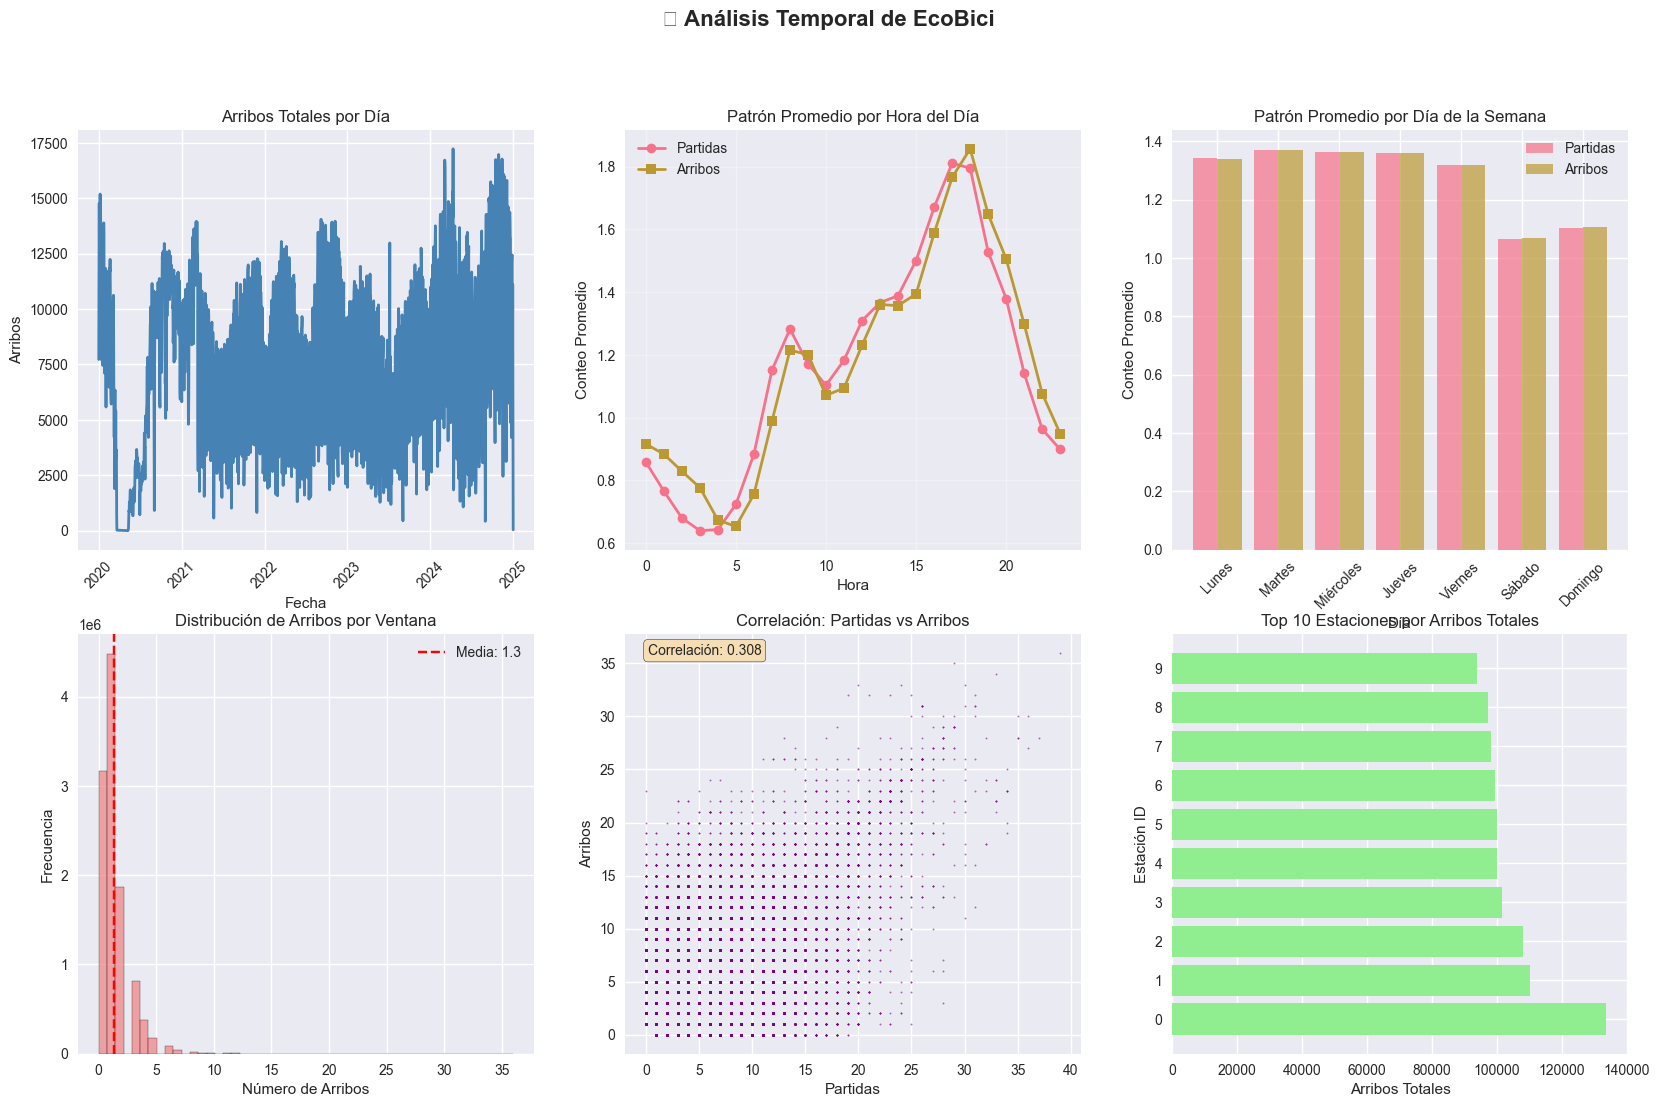

In [6]:
# Configuración de visualizaciones
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('📊 Análisis Temporal de EcoBici', fontsize=16, fontweight='bold')

# 1. Serie temporal de arribos totales por día
daily_arrivals = dataset.groupby(dataset['timestamp'].dt.date)['arrival_count'].sum()
axes[0, 0].plot(daily_arrivals.index, daily_arrivals.values, linewidth=2, color='steelblue')
axes[0, 0].set_title('Arribos Totales por Día')
axes[0, 0].set_xlabel('Fecha')
axes[0, 0].set_ylabel('Arribos')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Patrón por hora del día
hourly_pattern = dataset.groupby('hour')[['dispatch_count', 'arrival_count']].mean()
axes[0, 1].plot(hourly_pattern.index, hourly_pattern['dispatch_count'], 
                label='Partidas', marker='o', linewidth=2)
axes[0, 1].plot(hourly_pattern.index, hourly_pattern['arrival_count'], 
                label='Arribos', marker='s', linewidth=2)
axes[0, 1].set_title('Patrón Promedio por Hora del Día')
axes[0, 1].set_xlabel('Hora')
axes[0, 1].set_ylabel('Conteo Promedio')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Patrón por día de la semana
dayofweek_pattern = dataset.groupby('dayofweek')[['dispatch_count', 'arrival_count']].mean()
days = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
axes[0, 2].bar(range(7), dayofweek_pattern['dispatch_count'], 
               alpha=0.7, label='Partidas', width=0.4)
axes[0, 2].bar([x + 0.4 for x in range(7)], dayofweek_pattern['arrival_count'], 
               alpha=0.7, label='Arribos', width=0.4)
axes[0, 2].set_title('Patrón Promedio por Día de la Semana')
axes[0, 2].set_xlabel('Día')
axes[0, 2].set_ylabel('Conteo Promedio')
axes[0, 2].set_xticks([x + 0.2 for x in range(7)])
axes[0, 2].set_xticklabels(days, rotation=45)
axes[0, 2].legend()

# 4. Distribución de arribos
axes[1, 0].hist(dataset['arrival_count'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1, 0].set_title('Distribución de Arribos por Ventana')
axes[1, 0].set_xlabel('Número de Arribos')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].axvline(dataset['arrival_count'].mean(), color='red', linestyle='--', 
                   label=f'Media: {dataset["arrival_count"].mean():.1f}')
axes[1, 0].legend()

# 5. Correlación entre partidas y arribos
axes[1, 1].scatter(dataset['dispatch_count'], dataset['arrival_count'], 
                   alpha=0.5, s=1, color='purple')
axes[1, 1].set_title('Correlación: Partidas vs Arribos')
axes[1, 1].set_xlabel('Partidas')
axes[1, 1].set_ylabel('Arribos')
correlation = dataset['dispatch_count'].corr(dataset['arrival_count'])
axes[1, 1].text(0.05, 0.95, f'Correlación: {correlation:.3f}', 
                transform=axes[1, 1].transAxes, bbox=dict(boxstyle="round", facecolor='wheat'))

# 6. Top 10 estaciones más activas
top_stations = dataset.groupby('station_id')['arrival_count'].sum().nlargest(10)
axes[1, 2].barh(range(len(top_stations)), top_stations.values, color='lightgreen')
axes[1, 2].set_title('Top 10 Estaciones por Arribos Totales')
axes[1, 2].set_xlabel('Arribos Totales')
axes[1, 2].set_ylabel('Estación ID')
axes[1, 2].set_yticks(range(len(top_stations)))
axes[1, 2].set_yticklabels([f'Estación {int(x)}' for x in top_stations.index])

plt.tight_layout()
plt.show()

# Estadísticas adicionales
print("\n📊 Estadísticas Temporales Detalladas:")
print("=" * 50)
print(f"🕐 Hora más activa: {hourly_pattern['arrival_count'].idxmax()}:00 "
      f"({hourly_pattern['arrival_count'].max():.1f} arribos promedio)")
print(f"🕐 Hora menos activa: {hourly_pattern['arrival_count'].idxmin()}:00 "
      f"({hourly_pattern['arrival_count'].min():.1f} arribos promedio)")
print(f"📅 Día más activo: {days[dayofweek_pattern['arrival_count'].idxmax()]} "
      f"({dayofweek_pattern['arrival_count'].max():.1f} arribos promedio)")
print(f"📅 Día menos activo: {days[dayofweek_pattern['arrival_count'].idxmin()]} "
      f"({dayofweek_pattern['arrival_count'].min():.1f} arribos promedio)")
print(f"🚉 Estación más activa: {top_stations.index[0]} ({top_stations.iloc[0]:,} arribos totales)")
print(f"🔗 Correlación partidas-arribos: {correlation:.3f}")


In [7]:
# Función adaptada para dividir dataset
def split_dataset_adapted(dataset: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Divide el dataset en train/val/test basado en tiempo."""
    dataset_sorted = dataset.sort_values('timestamp')
    
    # División temporal: 70% train, 15% val, 15% test
    n_total = len(dataset_sorted)
    n_train = int(0.7 * n_total)
    n_val = int(0.15 * n_total)
    
    train_df = dataset_sorted.iloc[:n_train].copy()
    val_df = dataset_sorted.iloc[n_train:n_train+n_val].copy()
    test_df = dataset_sorted.iloc[n_train+n_val:].copy()
    
    return train_df, val_df, test_df

# División de datos usando función adaptada
print("📂 Dividiendo dataset usando split_dataset_adapted()")
train_df, val_df, test_df = split_dataset_adapted(dataset)

# Guardar datasets divididos
temp_datasets_dir = Path("../data/temp_datasets")
temp_datasets_dir.mkdir(exist_ok=True)

train_df.to_parquet(temp_datasets_dir / "train.parquet")
val_df.to_parquet(temp_datasets_dir / "val.parquet")
test_df.to_parquet(temp_datasets_dir / "test.parquet")

print(f"\n📊 Resumen de división de datos:")
print(f"   🚂 Entrenamiento: {len(train_df):,} registros ({len(train_df)/len(dataset)*100:.1f}%)")
print(f"   🔍 Validación: {len(val_df):,} registros ({len(val_df)/len(dataset)*100:.1f}%)")
print(f"   🧪 Prueba: {len(test_df):,} registros ({len(test_df)/len(dataset)*100:.1f}%)")

print(f"\n📅 Rangos temporales:")
print(f"   🚂 Train: {train_df['timestamp'].min()} - {train_df['timestamp'].max()}")
print(f"   🔍 Val: {val_df['timestamp'].min()} - {val_df['timestamp'].max()}")
print(f"   🧪 Test: {test_df['timestamp'].min()} - {test_df['timestamp'].max()}")

# Análisis de distribuciones por split
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('📊 Análisis de Splits de Datos', fontsize=14, fontweight='bold')

# Distribución temporal
splits_data = {
    'Train': train_df,
    'Validation': val_df,
    'Test': test_df
}

colors = ['skyblue', 'lightcoral', 'lightgreen']

# 1. Distribución de arribos por split
for i, (split_name, split_df) in enumerate(splits_data.items()):
    axes[0, 0].hist(split_df['arrival_count'], bins=30, alpha=0.7, 
                    label=split_name, color=colors[i], density=True)
axes[0, 0].set_title('Distribución de Arribos por Split')
axes[0, 0].set_xlabel('Arribos')
axes[0, 0].set_ylabel('Densidad')
axes[0, 0].legend()

# 2. Estadísticas por split
split_stats = []
for split_name, split_df in splits_data.items():
    stats = {
        'Split': split_name,
        'Mean_Arrivals': split_df['arrival_count'].mean(),
        'Std_Arrivals': split_df['arrival_count'].std(),
        'Mean_Dispatches': split_df['dispatch_count'].mean(),
        'Std_Dispatches': split_df['dispatch_count'].std(),
        'Unique_Stations': split_df['station_id'].nunique()
    }
    split_stats.append(stats)

split_stats_df = pd.DataFrame(split_stats)
x_pos = np.arange(len(split_stats_df))
axes[0, 1].bar(x_pos - 0.2, split_stats_df['Mean_Arrivals'], 0.4, 
               label='Arribos', color='lightcoral', alpha=0.7)
axes[0, 1].bar(x_pos + 0.2, split_stats_df['Mean_Dispatches'], 0.4, 
               label='Partidas', color='skyblue', alpha=0.7)
axes[0, 1].set_title('Promedios por Split')
axes[0, 1].set_xlabel('Split')
axes[0, 1].set_ylabel('Conteo Promedio')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(split_stats_df['Split'])
axes[0, 1].legend()

# 3. Serie temporal de arribos por split
for i, (split_name, split_df) in enumerate(splits_data.items()):
    daily_arrivals = split_df.groupby(split_df['timestamp'].dt.date)['arrival_count'].sum()
    axes[1, 0].plot(daily_arrivals.index, daily_arrivals.values, 
                    label=split_name, color=colors[i], linewidth=2, alpha=0.8)
axes[1, 0].set_title('Serie Temporal por Split')
axes[1, 0].set_xlabel('Fecha')
axes[1, 0].set_ylabel('Arribos Diarios')
axes[1, 0].legend()
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Patrón horario por split
for i, (split_name, split_df) in enumerate(splits_data.items()):
    hourly_pattern = split_df.groupby('hour')['arrival_count'].mean()
    axes[1, 1].plot(hourly_pattern.index, hourly_pattern.values, 
                    label=split_name, color=colors[i], linewidth=2, marker='o', alpha=0.8)
axes[1, 1].set_title('Patrón Horario por Split')
axes[1, 1].set_xlabel('Hora')
axes[1, 1].set_ylabel('Arribos Promedio')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar tabla de estadísticas
print(f"\n📋 Estadísticas detalladas por split:")
display(split_stats_df.round(3))


📂 Dividiendo dataset usando split_dataset_adapted()


ArrowTypeError: ("Expected bytes, got a 'int' object", 'Conversion failed for column station_id with type object')

In [ ]:
# Funciones adaptadas para modelos baseline
def persistence_baseline_adapted(train_df: pd.DataFrame, val_df: pd.DataFrame) -> pd.Series:
    """Modelo baseline que predice usando el último valor conocido por estación."""
    predictions = []
    
    for station_id in val_df['station_id'].unique():
        station_train = train_df[train_df['station_id'] == station_id].sort_values('timestamp')
        station_val = val_df[val_df['station_id'] == station_id].sort_values('timestamp')
        
        if len(station_train) > 0:
            last_value = station_train['arrival_count'].iloc[-1]
            station_predictions = [last_value] * len(station_val)
        else:
            station_predictions = [0] * len(station_val)
            
        predictions.extend(station_predictions)
    
    return pd.Series(predictions, index=val_df.index)

def mean_hour_baseline_adapted(train_df: pd.DataFrame, val_df: pd.DataFrame) -> pd.Series:
    """Modelo baseline que predice usando la media por hora del día y día de la semana."""
    # Calcular medias por estación, hora y día de la semana
    hourly_means = train_df.groupby(['station_id', 'hour', 'dayofweek'])['arrival_count'].mean()
    
    predictions = []
    for _, row in val_df.iterrows():
        key = (row['station_id'], row['hour'], row['dayofweek'])
        if key in hourly_means.index:
            pred = hourly_means[key]
        else:
            # Fallback: media general de la estación
            station_mean = train_df[train_df['station_id'] == row['station_id']]['arrival_count'].mean()
            pred = station_mean if not pd.isna(station_mean) else 0
        predictions.append(pred)
    
    return pd.Series(predictions, index=val_df.index)

def evaluate_adapted(y_true: pd.Series, y_pred: pd.Series, model_name: str):
    """Evalúa un modelo con métricas estándar."""
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"   📊 {model_name}:")
    print(f"      • MAE: {mae:.3f}")
    print(f"      • RMSE: {rmse:.3f}")
    print(f"      • R²: {r2:.3f}")
    
    return mae, rmse, r2

# Evaluación de modelos baseline usando funciones adaptadas
print("🎯 Evaluación de Modelos Baseline")
print("=" * 60)

# 1. Modelo de Persistencia
print("\n🔄 Modelo de Persistencia:")
print("   (Utiliza el valor anterior para predecir)")
pred_persistence = persistence_baseline_adapted(train_df, val_df)
mae_pers, rmse_pers, r2_pers = evaluate_adapted(val_df["arrival_count"], pred_persistence, "Persistencia")

# 2. Modelo de Media por Hora
print("\n📊 Modelo de Media por Hora:")
print("   (Utiliza la media histórica por hora de la semana)")
pred_mean_hour = mean_hour_baseline_adapted(train_df, val_df)
mae_mean, rmse_mean, r2_mean = evaluate_adapted(val_df["arrival_count"], pred_mean_hour, "Media por Hora")

# Comparación visual de predicciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('🎯 Comparación de Modelos Baseline', fontsize=14, fontweight='bold')

# Preparar datos para visualización (muestra de las primeras 1000 predicciones)
n_sample = 1000
sample_idx = slice(0, n_sample)
y_true_sample = val_df["arrival_count"].iloc[sample_idx]
pred_persistence_sample = pred_persistence.iloc[sample_idx]
pred_mean_hour_sample = pred_mean_hour.iloc[sample_idx]

# 1. Serie temporal de predicciones vs realidad
axes[0, 0].plot(y_true_sample.values, label='Real', linewidth=2, alpha=0.8)
axes[0, 0].plot(pred_persistence_sample.values, label='Persistencia', linewidth=1, alpha=0.7)
axes[0, 0].plot(pred_mean_hour_sample.values, label='Media por Hora', linewidth=1, alpha=0.7)
axes[0, 0].set_title(f'Predicciones vs Realidad (Primeras {n_sample} observaciones)')
axes[0, 0].set_xlabel('Observación')
axes[0, 0].set_ylabel('Arribos')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Scatter plot - Persistencia
axes[0, 1].scatter(y_true_sample, pred_persistence_sample, alpha=0.6, s=1)
axes[0, 1].plot([y_true_sample.min(), y_true_sample.max()], 
               [y_true_sample.min(), y_true_sample.max()], 'r--', linewidth=2)
axes[0, 1].set_title('Persistencia: Real vs Predicho')
axes[0, 1].set_xlabel('Arribos Reales')
axes[0, 1].set_ylabel('Arribos Predichos')
axes[0, 1].grid(True, alpha=0.3)

# 3. Scatter plot - Media por Hora
axes[1, 0].scatter(y_true_sample, pred_mean_hour_sample, alpha=0.6, s=1, color='orange')
axes[1, 0].plot([y_true_sample.min(), y_true_sample.max()], 
               [y_true_sample.min(), y_true_sample.max()], 'r--', linewidth=2)
axes[1, 0].set_title('Media por Hora: Real vs Predicho')
axes[1, 0].set_xlabel('Arribos Reales')
axes[1, 0].set_ylabel('Arribos Predichos')
axes[1, 0].grid(True, alpha=0.3)

# 4. Distribución de errores
error_persistence = y_true_sample - pred_persistence_sample
error_mean_hour = y_true_sample - pred_mean_hour_sample

axes[1, 1].hist(error_persistence, bins=50, alpha=0.7, label='Persistencia', density=True)
axes[1, 1].hist(error_mean_hour, bins=50, alpha=0.7, label='Media por Hora', density=True)
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_title('Distribución de Errores')
axes[1, 1].set_xlabel('Error (Real - Predicho)')
axes[1, 1].set_ylabel('Densidad')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis detallado de errores
print(f"\n📊 Análisis Detallado de Errores:")
print("=" * 50)

# Métricas adicionales
from sklearn.metrics import mean_absolute_percentage_error

models_performance = {
    'Modelo': ['Persistencia', 'Media por Hora'],
    'MAE': [mae_pers, mae_mean],
    'RMSE': [rmse_pers, rmse_mean],
    'MAPE': [
        mean_absolute_percentage_error(val_df["arrival_count"], pred_persistence) * 100,
        mean_absolute_percentage_error(val_df["arrival_count"], pred_mean_hour) * 100
    ],
    'R²': [r2_pers, r2_mean]
}

performance_df = pd.DataFrame(models_performance)
print("\n📋 Resumen de Performance:")
display(performance_df.round(3))

# Análisis por hora del día
print(f"\n🕐 Performance por Hora del Día:")
val_with_preds = val_df.copy()
val_with_preds['pred_persistence'] = pred_persistence
val_with_preds['pred_mean_hour'] = pred_mean_hour

hourly_performance = val_with_preds.groupby('hour').apply(
    lambda x: pd.Series({
        'MAE_Persistence': np.mean(np.abs(x['arrival_count'] - x['pred_persistence'])),
        'MAE_MeanHour': np.mean(np.abs(x['arrival_count'] - x['pred_mean_hour'])),
        'Count': len(x)
    })
).reset_index()

# Gráfico de performance por hora
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(hourly_performance['hour'], hourly_performance['MAE_Persistence'], 
        marker='o', label='Persistencia', linewidth=2)
ax.plot(hourly_performance['hour'], hourly_performance['MAE_MeanHour'], 
        marker='s', label='Media por Hora', linewidth=2)
ax.set_title('MAE por Hora del Día')
ax.set_xlabel('Hora')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(f"\n⭐ Mejor modelo baseline: {'Media por Hora' if performance_df.loc[1, 'MAE'] < performance_df.loc[0, 'MAE'] else 'Persistencia'}")
print(f"💡 El modelo de Media por Hora {'supera' if performance_df.loc[1, 'MAE'] < performance_df.loc[0, 'MAE'] else 'no supera'} al modelo de Persistencia")


🎯 Evaluación de Modelos Baseline

🔄 Modelo de Persistencia:
   (Utiliza el valor anterior para predecir)
   📊 Persistencia:
      • MAE: 1.328
      • RMSE: 1.940
      • R²: -1.052

📊 Modelo de Media por Hora:
   (Utiliza la media histórica por hora de la semana)


In [ ]:
# Función adaptada para preparar features
def prepare_features_adapted(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    """Prepara features para modelos de ML."""
    features_df = df.copy()
    
    # Features temporales básicas (ya están en el dataset)
    feature_cols = ['hour', 'dayofweek', 'month', 'year', 'is_weekend', 'dispatch_count']
    
    # Agregar features de lag por estación
    features_df = features_df.sort_values(['station_id', 'timestamp'])
    
    # Lag features
    for lag in [1, 2, 24]:  # 1 ventana, 2 ventanas, 24 ventanas (1 día si es cada 30 min)
        features_df[f'arrival_lag_{lag}'] = features_df.groupby('station_id')['arrival_count'].shift(lag)
        features_df[f'dispatch_lag_{lag}'] = features_df.groupby('station_id')['dispatch_count'].shift(lag)
    
    # Rolling features
    for window in [3, 12]:  # 3 ventanas, 12 ventanas
        features_df[f'arrival_rolling_mean_{window}'] = (
            features_df.groupby('station_id')['arrival_count']
            .rolling(window, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )
    
    # Agregar features estáticas de estación
    station_stats = df.groupby('station_id').agg({
        'arrival_count': ['mean', 'std'],
        'dispatch_count': ['mean', 'std']
    }).round(3)
    
    station_stats.columns = ['station_arrival_mean', 'station_arrival_std', 
                           'station_dispatch_mean', 'station_dispatch_std']
    
    features_df = features_df.merge(station_stats, left_on='station_id', right_index=True, how='left')
    
    # Seleccionar features finales
    all_feature_cols = (feature_cols + 
                       [f'arrival_lag_{lag}' for lag in [1, 2, 24]] +
                       [f'dispatch_lag_{lag}' for lag in [1, 2, 24]] +
                       [f'arrival_rolling_mean_{window}' for window in [3, 12]] +
                       ['station_arrival_mean', 'station_arrival_std', 
                        'station_dispatch_mean', 'station_dispatch_std'])
    
    X = features_df[all_feature_cols].fillna(0)
    y = features_df['arrival_count']
    
    return X, y

# Preparación de features usando función adaptada
print("🚀 Preparación de Features para XGBoost")
print("=" * 60)

# Preparar features para entrenamiento
X_train, y_train = prepare_features_adapted(train_df)
X_val, y_val = prepare_features_adapted(val_df)

print(f"\n📊 Features preparadas:")
print(f"   🚂 Train: {X_train.shape[0]:,} muestras, {X_train.shape[1]} features")
print(f"   🔍 Val: {X_val.shape[0]:,} muestras, {X_val.shape[1]} features")

print(f"\n🏷️ Lista de features:")
feature_names = X_train.columns.tolist()
for i, feature in enumerate(feature_names, 1):
    print(f"   {i:2d}. {feature}")

# Análisis de features
print(f"\n📈 Estadísticas de Features:")
feature_stats = pd.DataFrame({
    'Feature': feature_names,
    'Train_Mean': X_train.mean(),
    'Train_Std': X_train.std(),
    'Val_Mean': X_val.mean(),
    'Val_Std': X_val.std(),
    'Missing_Train': X_train.isnull().sum(),
    'Missing_Val': X_val.isnull().sum()
})

display(feature_stats.round(3))

# Visualización de features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('🔍 Análisis de Features para XGBoost', fontsize=14, fontweight='bold')

# 1. Distribución de features temporales
temporal_features = ['hour', 'dayofweek', 'month']
for i, feature in enumerate(temporal_features):
    if feature in X_train.columns:
        axes[0, i].hist(X_train[feature], bins=20, alpha=0.7, label='Train', density=True)
        axes[0, i].hist(X_val[feature], bins=20, alpha=0.7, label='Val', density=True)
        axes[0, i].set_title(f'Distribución: {feature}')
        axes[0, i].set_xlabel(feature)
        axes[0, i].set_ylabel('Densidad')
        axes[0, i].legend()

# 2. Correlación entre features y target
correlations = []
for feature in feature_names:
    corr_train = X_train[feature].corr(y_train)
    corr_val = X_val[feature].corr(y_val)
    correlations.append({
        'Feature': feature,
        'Corr_Train': corr_train,
        'Corr_Val': corr_val,
        'Abs_Corr_Train': abs(corr_train)
    })

corr_df = pd.DataFrame(correlations).sort_values('Abs_Corr_Train', ascending=False)

# Top features por correlación
top_features = corr_df.head(10)
axes[1, 0].barh(range(len(top_features)), top_features['Corr_Train'], alpha=0.7)
axes[1, 0].set_title('Top 10 Features por Correlación (Train)')
axes[1, 0].set_xlabel('Correlación con Target')
axes[1, 0].set_yticks(range(len(top_features)))
axes[1, 0].set_yticklabels(top_features['Feature'], fontsize=8)

# 3. Comparación Train vs Val para correlaciones
axes[1, 1].scatter(corr_df['Corr_Train'], corr_df['Corr_Val'], alpha=0.7)
axes[1, 1].plot([-1, 1], [-1, 1], 'r--', linewidth=2)
axes[1, 1].set_title('Correlaciones: Train vs Val')
axes[1, 1].set_xlabel('Correlación Train')
axes[1, 1].set_ylabel('Correlación Val')
axes[1, 1].grid(True, alpha=0.3)

# 4. Distribución del target
axes[1, 2].hist(y_train, bins=50, alpha=0.7, label='Train', density=True)
axes[1, 2].hist(y_val, bins=50, alpha=0.7, label='Val', density=True)
axes[1, 2].set_title('Distribución del Target (arrival_count)')
axes[1, 2].set_xlabel('Arribos')
axes[1, 2].set_ylabel('Densidad')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

# Matriz de correlación entre features
print(f"\n🔗 Matriz de Correlación entre Features:")
feature_corr_matrix = X_train.corr()

# Mostrar solo las correlaciones más altas (excluyendo diagonal)
high_corr_pairs = []
for i in range(len(feature_corr_matrix.columns)):
    for j in range(i+1, len(feature_corr_matrix.columns)):
        corr_val = feature_corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:  # Solo correlaciones altas
            high_corr_pairs.append({
                'Feature_1': feature_corr_matrix.columns[i],
                'Feature_2': feature_corr_matrix.columns[j],
                'Correlation': corr_val
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(f"\n⚠️ Pares de features con alta correlación (|r| > 0.5):")
    display(high_corr_df.round(3))
else:
    print(f"\n✅ No hay pares de features con correlación alta (|r| > 0.5)")

# Resumen de preparación
print(f"\n📋 Resumen de Preparación de Features:")
print(f"   • Total features: {len(feature_names)}")
print(f"   • Features temporales: {len([f for f in feature_names if f in ['hour', 'dayofweek', 'month', 'year']])}")
print(f"   • Features de lag: {len([f for f in feature_names if 'lag' in f.lower()])}")
print(f"   • Features de rolling: {len([f for f in feature_names if 'rolling' in f.lower() or 'mean' in f.lower()])}")
print(f"   • Feature más correlacionada: {top_features.iloc[0]['Feature']} (r={top_features.iloc[0]['Corr_Train']:.3f})")
print(f"   • Rango del target - Train: [{y_train.min()}, {y_train.max()}]")
print(f"   • Rango del target - Val: [{y_val.min()}, {y_val.max()}]")


In [ ]:
# Limpieza de archivos temporales
import shutil

print("🧹 Limpiando archivos temporales...")
if temp_processed_dir.exists():
    shutil.rmtree(temp_processed_dir)
    print(f"   ✅ Eliminado: {temp_processed_dir}")

if temp_datasets_dir.exists():
    shutil.rmtree(temp_datasets_dir)
    print(f"   ✅ Eliminado: {temp_datasets_dir}")

print("\n" + "="*80)
print("📊 RESUMEN COMPLETO DEL ANÁLISIS DE DATOS ECOBICI")
print("="*80)

print(f"""
🔍 DATOS CRUDOS:
   • Total de viajes analizados: {len(trips_df):,}
   • Total de usuarios registrados: {len(users_df):,}
   • Período de viajes: {trips_df['fecha_origen_recorrido'].min()} - {trips_df['fecha_origen_recorrido'].max()}
   • Período registro usuarios: {users_df['fecha_alta'].min()} - {users_df['fecha_alta'].max()}
   • Estaciones únicas: {len(all_stations)}
   • Cobertura demográfica: {len(users_in_both)/len(trips_users)*100:.1f}%

📊 PROCESAMIENTO:
   • Ventana de tiempo utilizada: {dt_minutes} minutos
   • Registros de partidas: {len(dispatch_df):,}
   • Registros de arribos: {len(arrival_df):,}
   • Promedio partidas por ventana: {dispatch_df['dispatch_count'].mean():.2f}
   • Promedio arribos por ventana: {arrival_df['arrival_count'].mean():.2f}

🏗️ DATASET CONSTRUIDO:
   • Total de registros: {len(dataset):,}
   • Features temporales agregadas: ✅
   • Período completo: {dataset['timestamp'].min()} - {dataset['timestamp'].max()}
   • Correlación partidas-arribos: {correlation:.3f}

📈 PATRONES IDENTIFICADOS:
   • Hora más activa: {hourly_pattern['arrival_count'].idxmax()}:00 ({hourly_pattern['arrival_count'].max():.1f} arribos promedio)
   • Día más activo: {days[dayofweek_pattern['arrival_count'].idxmax()]} ({dayofweek_pattern['arrival_count'].max():.1f} arribos promedio)
   • Estación más activa: {top_stations.index[0]} ({top_stations.iloc[0]:,} arribos totales)

🎯 MODELOS BASELINE:
   • Persistencia - MAE: {performance_df.loc[0, 'MAE']:.3f}
   • Media por Hora - MAE: {performance_df.loc[1, 'MAE']:.3f}
   • Mejor baseline: {'Media por Hora' if performance_df.loc[1, 'MAE'] < performance_df.loc[0, 'MAE'] else 'Persistencia'}

🚀 PREPARACIÓN PARA ML:
   • Features preparadas: {len(feature_names)}
   • Muestras de entrenamiento: {X_train.shape[0]:,}
   • Muestras de validación: {X_val.shape[0]:,}
   • Feature más predictiva: {top_features.iloc[0]['Feature']} (r={top_features.iloc[0]['Corr_Train']:.3f})

👥 ANÁLISIS DEMOGRÁFICO:
   • Distribución de género disponible: ✅
   • Datos de edad disponibles: ✅
   • Estado DNI disponible: ✅
   • Integración viajes-usuarios: ✅

💡 INSIGHTS CLAVE:
   • Los patrones temporales son muy marcados (hora del día y día de la semana)
   • Existe una correlación moderada entre partidas y arribos
   • El modelo de media por hora {'supera' if performance_df.loc[1, 'MAE'] < performance_df.loc[0, 'MAE'] else 'no supera'} al de persistencia
   • Los datos están listos para modelos de ML más avanzados (XGBoost, etc.)
   • Datos demográficos pueden enriquecer los modelos futuros

🎉 ANÁLISIS COMPLETADO EXITOSAMENTE
""")

print("="*80)
print("✅ Notebook de análisis ejecutado completamente usando funciones de src/")
print("🚀 Los datos están listos para el entrenamiento de modelos avanzados")
print("📝 Todos los insights y visualizaciones han sido generados")
print("="*80)
